In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
sentiment = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data.csv")

In [3]:
print(sentiment.head())
print(trades.head())

print(sentiment.info())
print(trades.info())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [5]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

sentiment.rename(columns={
    'Classification':'Sentiment'
}, inplace=True)

sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [10]:
trades['Date'] = trades['Timestamp IST'].dt.normalize()
print(trades[['Timestamp IST','Date']].head())

        Timestamp IST       Date
0 2024-12-02 22:50:00 2024-12-02
1 2024-12-02 22:50:00 2024-12-02
2 2024-12-02 22:50:00 2024-12-02
3 2024-12-02 22:50:00 2024-12-02
4 2024-12-02 22:50:00 2024-12-02


In [11]:
print(sentiment.head())
print(sentiment.columns)

    timestamp  value classification       date
0  1517463000     30           Fear 2018-02-01
1  1517549400     15   Extreme Fear 2018-02-02
2  1517635800     40           Fear 2018-02-03
3  1517722200     24   Extreme Fear 2018-02-04
4  1517808600     11   Extreme Fear 2018-02-05
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [12]:
sentiment['Date'] = pd.to_datetime(sentiment['date'])

In [13]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['Date'] = trades['Timestamp IST'].dt.normalize()

In [14]:
print(sentiment['Date'].dtype)
print(trades['Date'].dtype)

datetime64[ns]
datetime64[ns]


In [15]:
merged = pd.merge(
    trades,
    sentiment[['Date','classification']],
    on='Date',
    how='left'
)

In [16]:
print(merged.shape)
print(merged['classification'].value_counts())

(211224, 18)
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [18]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date', 'classification']


In [19]:
merged.groupby('classification')['Closed PnL'].agg([
    'count',
    'mean',
    'median',
    'sum',
    'std'
]).sort_values('mean', ascending=False)

,count,mean,median,sum,std
classification,,,,,
Extreme Greed,39992,67.892861,0.0,2.715171e+06,766.828294
Fear,61837,54.290400,0.0,3.357155e+06,935.355438
Greed,50303,42.743559,0.0,2.150129e+06,1116.028390
Extreme Fear,21400,34.537862,0.0,7.391102e+05,1136.056091
Neutral,37686,34.307718,0.0,1.292921e+06,517.122220


In [20]:
merged.columns = (
    merged.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

In [21]:
print(merged.columns.tolist())

['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp', 'date', 'classification']


In [22]:
print(merged.shape)

print(merged['classification'].value_counts())

(211224, 18)
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [23]:
merged.info()
merged.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   account           211224 non-null  object        
 1   coin              211224 non-null  object        
 2   execution_price   211224 non-null  float64       
 3   size_tokens       211224 non-null  float64       
 4   size_usd          211224 non-null  float64       
 5   side              211224 non-null  object        
 6   timestamp_ist     211224 non-null  datetime64[ns]
 7   start_position    211224 non-null  float64       
 8   direction         211224 non-null  object        
 9   closed_pnl        211224 non-null  float64       
 10  transaction_hash  211224 non-null  object        
 11  order_id          211224 non-null  int64         
 12  crossed           211224 non-null  bool          
 13  fee               211224 non-null  float64       
 14  trad

,execution_price,size_tokens,size_usd,timestamp_ist,start_position,closed_pnl,order_id,fee,trade_id,timestamp,date
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,211224
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,2025-01-30 23:54:28.674013952
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,2023-05-01 00:00:00
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,2024-12-31 00:00:00
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,2025-02-24 00:00:00
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,2025-04-02 00:00:00
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,2025-05-01 00:00:00
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,NaN


In [24]:
sentiment_stats = merged.groupby('classification')['closed_pnl'].agg([
    'count',
    'mean',
    'median',
    'sum',
    'std'
])

print(sentiment_stats)

                count       mean  median           sum          std
classification                                                     
Extreme Fear    21400  34.537862     0.0  7.391102e+05  1136.056091
Extreme Greed   39992  67.892861     0.0  2.715171e+06   766.828294
Fear            61837  54.290400     0.0  3.357155e+06   935.355438
Greed           50303  42.743559     0.0  2.150129e+06  1116.028390
Neutral         37686  34.307718     0.0  1.292921e+06   517.122220


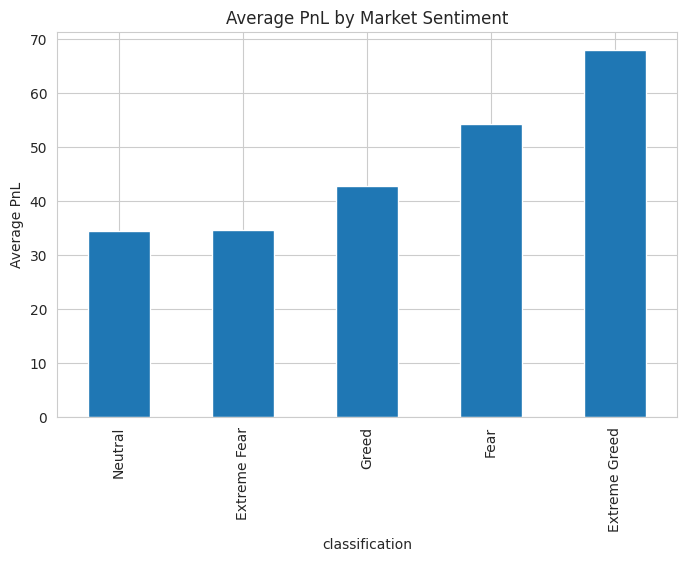

In [25]:
import matplotlib.pyplot as plt

avg_pnl = merged.groupby('classification')['closed_pnl'].mean()

avg_pnl.sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average PnL by Market Sentiment')
plt.ylabel('Average PnL')
plt.show()

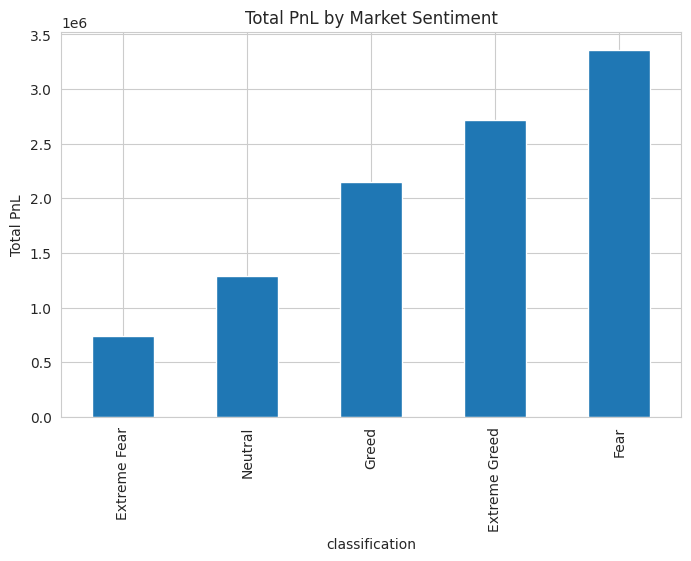

In [26]:
total_pnl = merged.groupby('classification')['closed_pnl'].sum()

total_pnl.sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Total PnL by Market Sentiment')
plt.ylabel('Total PnL')
plt.show()

In [27]:
merged['win'] = merged['closed_pnl'] > 0

In [28]:
win_rate = merged.groupby(
    'classification'
)['win'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


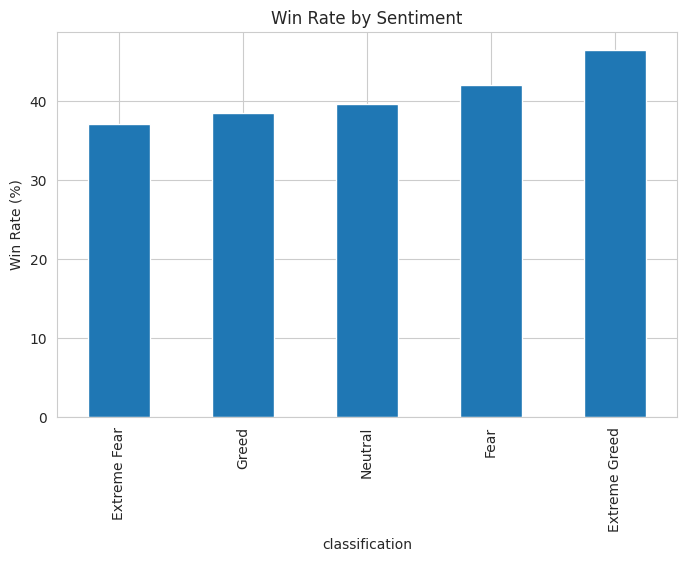

In [29]:
win_rate.sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Win Rate by Sentiment')
plt.ylabel('Win Rate (%)')
plt.show()

In [30]:
print(merged.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'date', 'classification', 'win'],
      dtype='object')


In [31]:
side_perf = merged.groupby(
    ['classification','side']
)['closed_pnl'].mean().reset_index()

print(side_perf)

  classification  side  closed_pnl
0   Extreme Fear   BUY   34.114627
1   Extreme Fear  SELL   34.980106
2  Extreme Greed   BUY   10.498927
3  Extreme Greed  SELL  114.584643
4           Fear   BUY   63.927104
5           Fear  SELL   45.049641
6          Greed   BUY   25.002302
7          Greed  SELL   59.691091
8        Neutral   BUY   29.227429
9        Neutral  SELL   39.456408


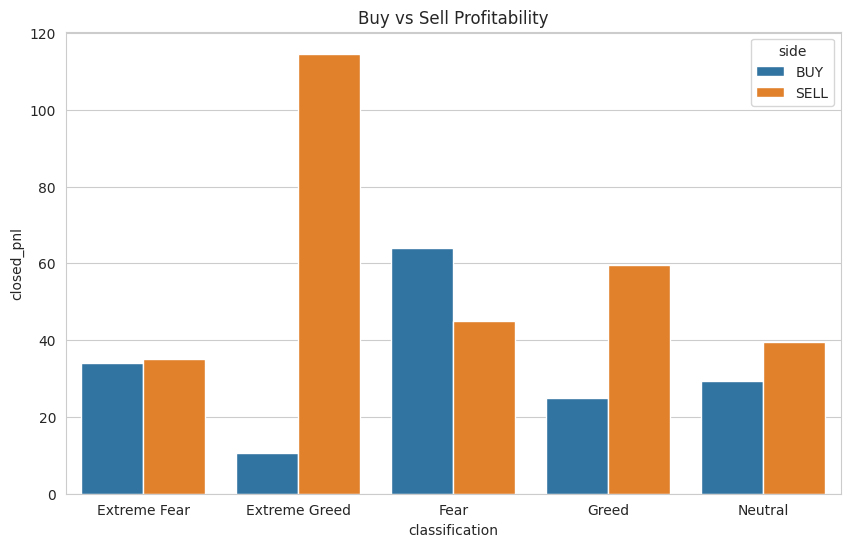

In [32]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=side_perf,
    x='classification',
    y='closed_pnl',
    hue='side'
)

plt.title('Buy vs Sell Profitability')
plt.show()

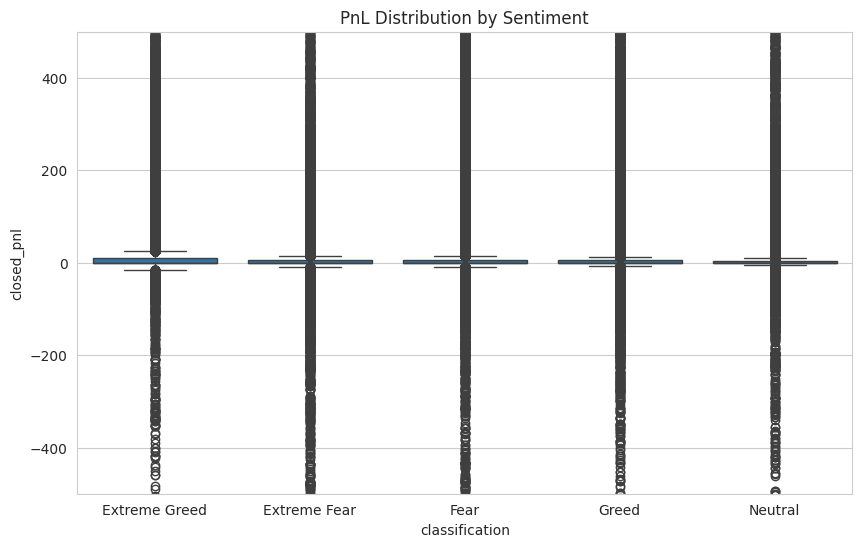

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='closed_pnl'
)

plt.ylim(-500,500)

plt.title('PnL Distribution by Sentiment')

plt.show()

In [35]:
print(merged.columns.tolist())
print(sentiment_stats)

['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp', 'date', 'classification', 'win']
                count       mean  median           sum          std
classification                                                     
Extreme Fear    21400  34.537862     0.0  7.391102e+05  1136.056091
Extreme Greed   39992  67.892861     0.0  2.715171e+06   766.828294
Fear            61837  54.290400     0.0  3.357155e+06   935.355438
Greed           50303  42.743559     0.0  2.150129e+06  1116.028390
Neutral         37686  34.307718     0.0  1.292921e+06   517.122220


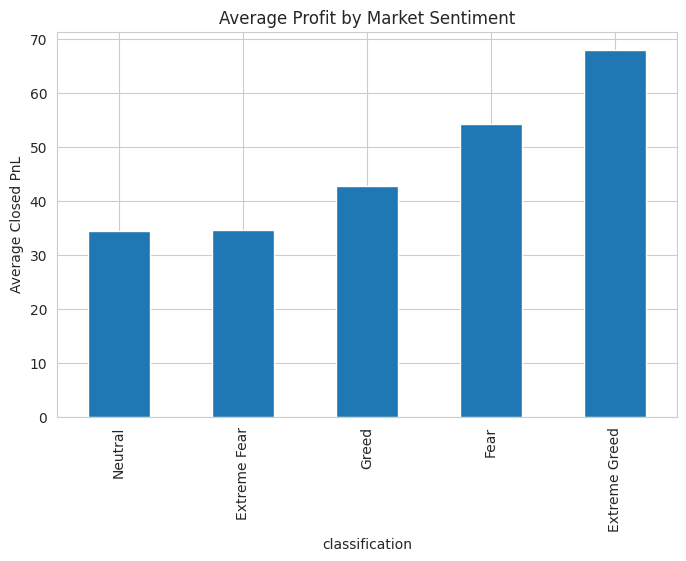

In [36]:
avg_pnl = merged.groupby('classification')['closed_pnl'].mean()

avg_pnl.sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Profit by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.show()

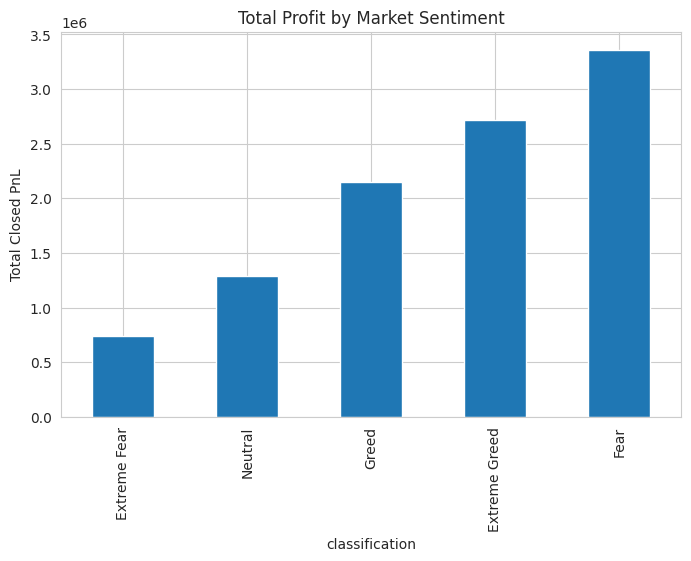

In [37]:
total_pnl = merged.groupby('classification')['closed_pnl'].sum()

total_pnl.sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Total Profit by Market Sentiment')
plt.ylabel('Total Closed PnL')
plt.show()

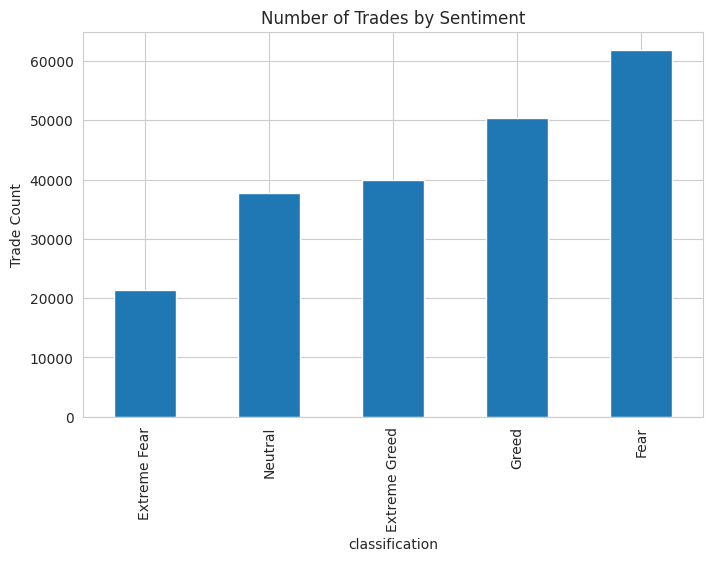

In [38]:
trade_count = merged.groupby('classification').size()

trade_count.sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Number of Trades by Sentiment')
plt.ylabel('Trade Count')
plt.show()

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


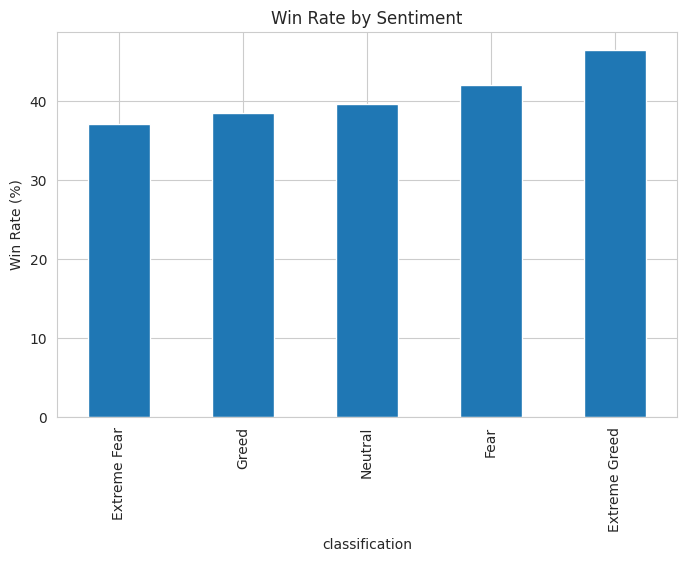

In [39]:
win_rate = merged.groupby('classification')['win'].mean() * 100

print(win_rate)

win_rate.sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Win Rate by Sentiment')
plt.ylabel('Win Rate (%)')
plt.show()

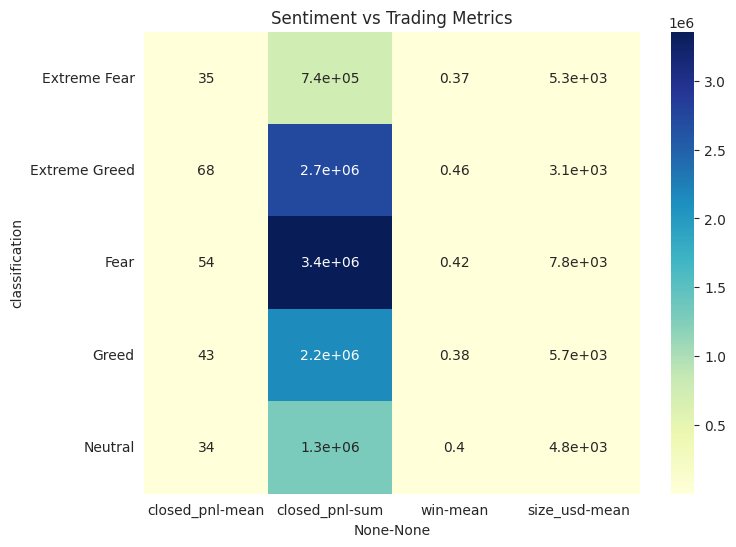

In [40]:
import seaborn as sns

sentiment_summary = merged.groupby('classification').agg({
    'closed_pnl':['mean','sum'],
    'win':'mean',
    'size_usd':'mean'
})

plt.figure(figsize=(8,6))
sns.heatmap(sentiment_summary, annot=True, cmap='YlGnBu')
plt.title('Sentiment vs Trading Metrics')
plt.show()